**Table of contents**<a id='toc0_'></a>    
- [Photoswitching fingerprints of 1 fluorophore - global bleaching times](#toc1_)    
  - [CDF Fitting procedure](#toc1_1_)    
  - [Reading and fitting data](#toc1_2_)    
    - [Bleaching rate data](#toc1_2_1_)    
    - [ON to OFF data](#toc1_2_2_)    
    - [OFF to ON data](#toc1_2_3_)    
  - [Figure](#toc1_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswitching fingerprints of 1 fluorophore - global bleaching times](#toc0_)

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lmfit import Model, Parameters
from matplotlib import rcParams

import fluopy.distributions as dist
import fluopy.figure as fi
import fluopy.miscellaneous as mi

%load_ext autoreload
%autoreload 2

reading_from = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\0_3_single_f_PFA"
saving_to = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_4_single_f_PFA_gl_bl_times"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[CDF Fitting procedure](#toc0_)

In [3]:
def target_cdf(x, p, lambda1, lambda2):
    mixture = dist.ExponentialMixtureModel(
        params={"pis": [p], "lambdas": [lambda1, lambda2]}, domain=(0, 300)
    )
    return mixture.cdf(x)


def fit_two_expon_mixture(data):
    x = np.linspace(0, 300, 300001)
    model = Model(target_cdf)
    params = Parameters()
    params.add("p", value=0.5, min=0, max=1)
    params.add("lambda1", value=1, min=0)
    params.add("lambda2", value=0.5, min=0)
    result = model.fit(data, params, x=x)
    parameters = [param.value for param in result.params.values()]

    return parameters

## <a id='toc1_2_'></a>[Reading and fitting data](#toc0_)

### <a id='toc1_2_1_'></a>[Bleaching rate data](#toc0_)

In [4]:
identifiers = ["1e1", "1e2", "1e3", "1e4"]
fingerprints_all_A = []
bleaching_times_all_A = []
parameters_all_fit_cdf_A = []
folder_path = reading_from + r"\bl_rate"
for i, id in enumerate(identifiers):
    fingerprints_all_A.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    bleaching_times_all_A.append([])
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            fingerprints_all_A[i] += pd.read_parquet(file).sum(axis=1)
        elif file.suffix == ".npy":
            bleaching_times_all_A[i] = np.load(file)
    fingerprint = fingerprints_all_A[i].cumsum() / fingerprints_all_A[i].sum()
    fingerprints_all_A[i] = fingerprint
    parameters_all_fit_cdf_A.append(fit_two_expon_mixture(fingerprint))

In [5]:
hists_A = []
bin_edges_log = np.logspace(np.log10(0.01), np.log10(300), 100)
for fingerprint in fingerprints_all_A:
    counts = fingerprint.diff().fillna(fingerprint.iloc[0]).values
    times_mid = fingerprint.index.values
    hist, bin_edges = np.histogram(times_mid, bins=bin_edges_log, weights=counts)
    hists_A.append(hist)

### <a id='toc1_2_2_'></a>[ON to OFF data](#toc0_)

In [6]:
identifiers = ["1", "01", "005", "001"]
fingerprints_all_B = []
bleaching_times_all_B = []
parameters_all_fit_cdf_B = []
folder_path = reading_from + r"\off_prob"
for i, id in enumerate(identifiers):
    fingerprints_all_B.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    bleaching_times_all_B.append([])
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            data = pd.read_parquet(file)
            fingerprints_all_B[i] += data.sum(axis=1)
        elif file.suffix == ".npy":
            bleaching_times_all_B[i] = np.load(file)
    fingerprint = fingerprints_all_B[i].cumsum() / fingerprints_all_B[i].sum()
    fingerprints_all_B[i] = fingerprint
    parameters_all_fit_cdf_B.append(fit_two_expon_mixture(fingerprint))

In [7]:
hists_B = []
bin_edges_log = np.logspace(np.log10(0.01), np.log10(300), 100)
for fingerprint in fingerprints_all_B:
    counts = fingerprint.diff().fillna(fingerprint.iloc[0]).values
    times_mid = fingerprint.index.values
    hist, bin_edges = np.histogram(times_mid, bins=bin_edges_log, weights=counts)
    hists_B.append(hist)

### <a id='toc1_2_3_'></a>[OFF to ON data](#toc0_)

In [8]:
identifiers = ["5e-2", "5e-1", "5e0", "5e1"]
fingerprints_all_C = []
bleaching_times_all_C = []
parameters_all_fit_cdf_C = []
folder_path = reading_from + r"\off_time"
for i, id in enumerate(identifiers):
    fingerprints_all_C.append(
        pd.Series(
            np.zeros(300001),
            np.round(np.linspace(0, 300, 300001), decimals=12),
            dtype=np.int32,
        )
    )
    bleaching_times_all_C.append([])
    for file in Path(folder_path + "\\" + id).iterdir():
        if file.suffix == ".parquet":
            data = pd.read_parquet(file)
            fingerprints_all_C[i] += data.sum(axis=1)
        elif file.suffix == ".npy":
            bleaching_times_all_C[i] = np.load(file)
    fingerprint = fingerprints_all_C[i].cumsum() / fingerprints_all_C[i].sum()
    fingerprints_all_C[i] = fingerprint
    parameters_all_fit_cdf_C.append(fit_two_expon_mixture(fingerprint))

In [9]:
hists_C = []
bin_edges_log = np.logspace(np.log10(0.01), np.log10(300), 100)
for fingerprint in fingerprints_all_C:
    counts = fingerprint.diff().fillna(fingerprint.iloc[0]).values
    times_mid = fingerprint.index.values
    hist, bin_edges = np.histogram(times_mid, bins=bin_edges_log, weights=counts)
    hists_C.append(hist)

## <a id='toc1_3_'></a>[Figure](#toc0_)

In [10]:
bin_widths = np.diff(bin_edges_log)
bin_centers = (bin_edges_log[:-1] + bin_edges_log[1:]) / 2

In [11]:
minima = []
for bleaching_times_all in [
    bleaching_times_all_A,
    bleaching_times_all_B,
    bleaching_times_all_C,
]:
    for bl_times in bleaching_times_all:
        bl_times = bl_times[:, 0][~np.isnan(bl_times[:, 0])]
        minimum = np.min(bl_times)
        minima.append(minimum)

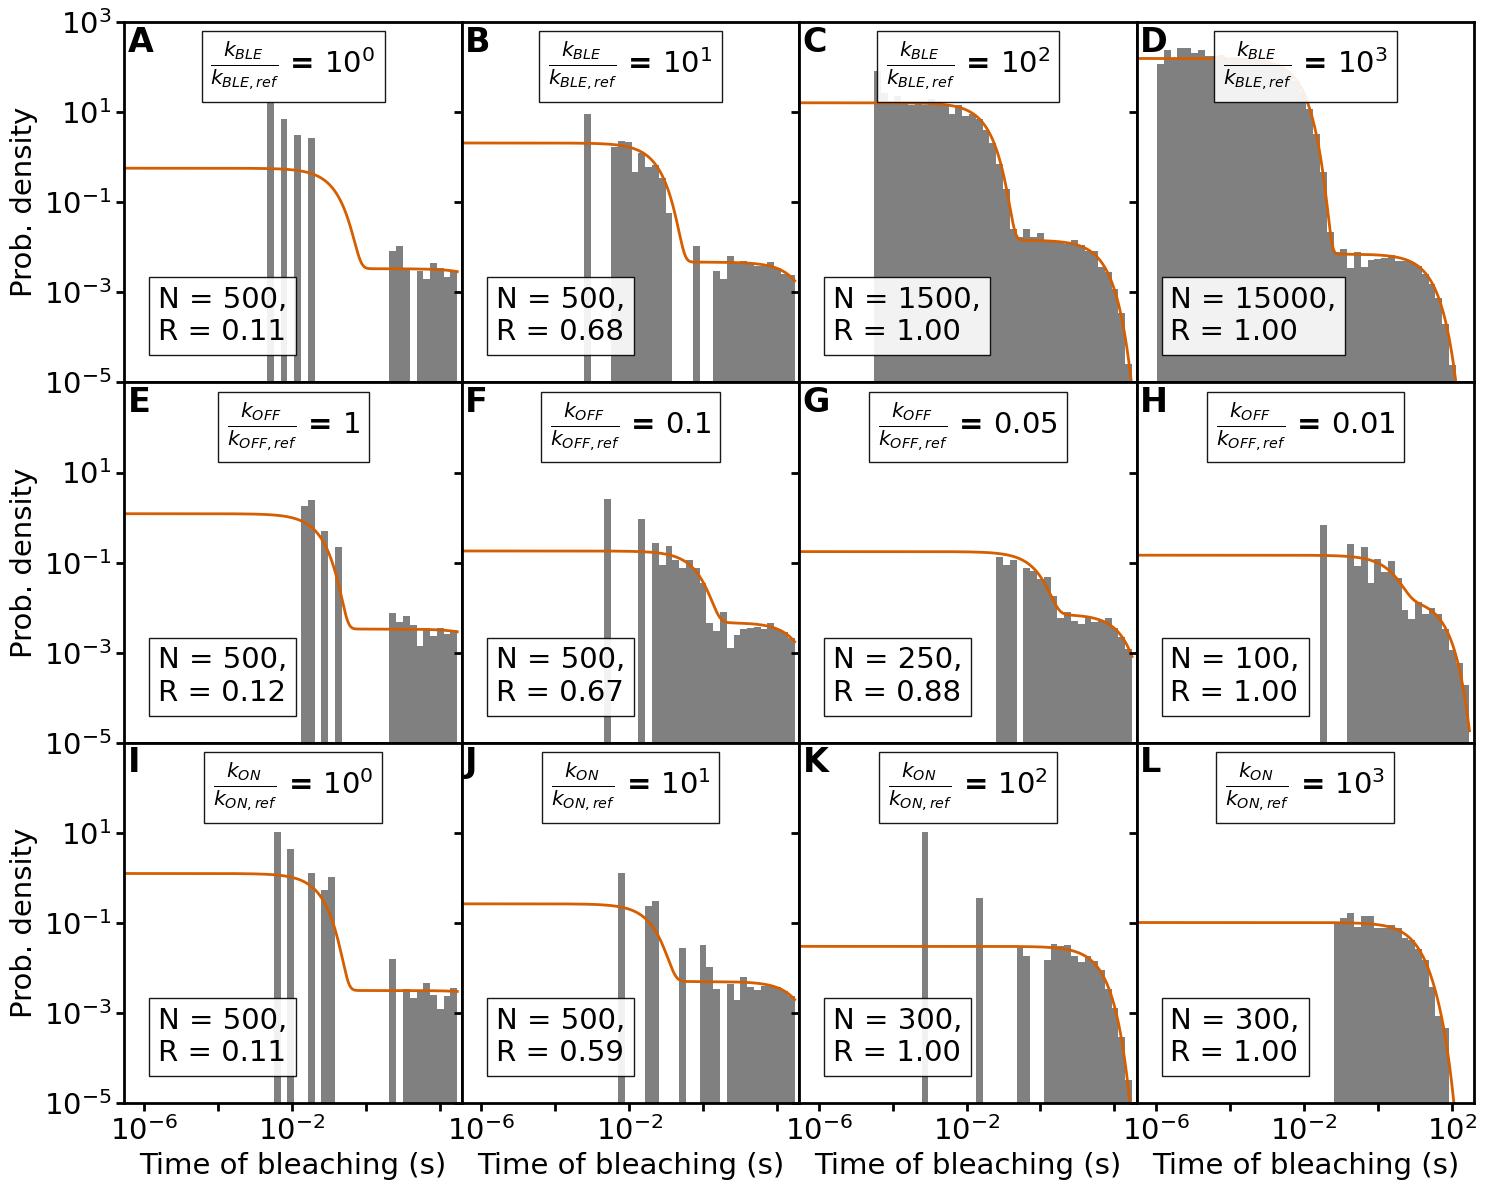

: 

In [ ]:
red = "#D55E00"
color = "grey"
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 4, wspace=0, hspace=0)
fig = plt.figure(figsize=(15, 12))
label1 = [
    r"$\frac{k_{BLE}}{k_{BLE,ref}}$",
    r"$\frac{k_{OFF}}{k_{OFF,ref}}$",
    r"$\frac{k_{ON}}{k_{ON,ref}}$",
]
label2 = [
    [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"],
    [r"$1$", r"$0.1$", r"$0.05$", r"$0.01$"],
    [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"],
]

for i, (bleaching_times_all, parameters_all_fit_cdf) in enumerate(
    zip(
        [bleaching_times_all_A, bleaching_times_all_B, bleaching_times_all_C],
        [parameters_all_fit_cdf_A, parameters_all_fit_cdf_B, parameters_all_fit_cdf_C],
    )
):
    for j, (bl_times, parameters) in enumerate(
        zip(bleaching_times_all, parameters_all_fit_cdf)
    ):
        pi, lambda1, lambda2 = parameters
        data = bl_times[:, 0][~np.isnan(bl_times[:, 0])]
        ratio = data.size / bl_times.shape[0]
        bins = np.logspace(np.log10(np.min(minima)), np.log10(300), 50)
        x = np.logspace(np.log10(np.min(minima)), np.log10(300), 1000)
        ax = fig.add_subplot(gs[i, j])
        fi.universal_figure(
            type_="hist", data=data, axes=ax, density=True, color=color, bins=bins
        )
        if i == 0 and j == 0:
            yticks = [1e-5, 1e-3, 1e-1, 1e1, 1e3]
        else:
            yticks = [1e-5, 1e-3, 1e-1, 1e1]
        if i == 2 and j == 3:
            xticklabels = dict(labels=[r"$10^{-6}$", "", r"$10^{-2}$", "", r"$10^{2}$"])
        else:
            xticklabels = dict(labels=[r"$10^{-6}$", "", r"$10^{-2}$", "", ""])
        fi.universal_figure(
            type_="line",
            data=[
                x,
                dist.ExponentialMixtureModel(
                    params={"pis": [pi], "lambdas": [lambda1, lambda2]}, domain=(0, 300)
                ).pdf(x),
            ],
            lw=2,
            axes=ax,
            yscale="log",
            xscale="log",
            xlabel="Time of bleaching (s)",
            ylabel="Prob. density",
            color=red,
            fontsize=21,
            ylim=[1e-5, 1e3],
            xlim=[np.min(minima), 400],
            xticks=[1e-6, 1e-4, 1e-2, 1e0, 1e2],
            xticklabels=xticklabels,
            yticks=yticks,
        )
        props = dict(boxstyle="square", facecolor="white", alpha=0.9, edgecolor="black")
        ax.text(
            0.5,
            0.95,
            f"{label1[i]} = {label2[i][j]}",
            transform=ax.transAxes,
            fontsize=21,
            fontweight="bold",
            va="top",
            ha="center",
            bbox=props,
        )
        ax.text(
            0.1,
            0.1,
            f"N = {bl_times.size},\nR = {ratio:.2f}",
            transform=ax.transAxes,
            fontsize=21,
            va="bottom",
            ha="left",
            bbox=props,
        )

axes = fig.get_axes()
letters = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"]
for i, axis in enumerate(axes):
    axis.text(
        0.01,
        0.99,
        letters[i],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="top",
        ha="left",
    )
    axis.label_outer()
fig.tight_layout()
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    saving_to + r"\single_f_PFA_gl_bl_times.png",
    dpi=300,
    bbox_inches=bbox,
)

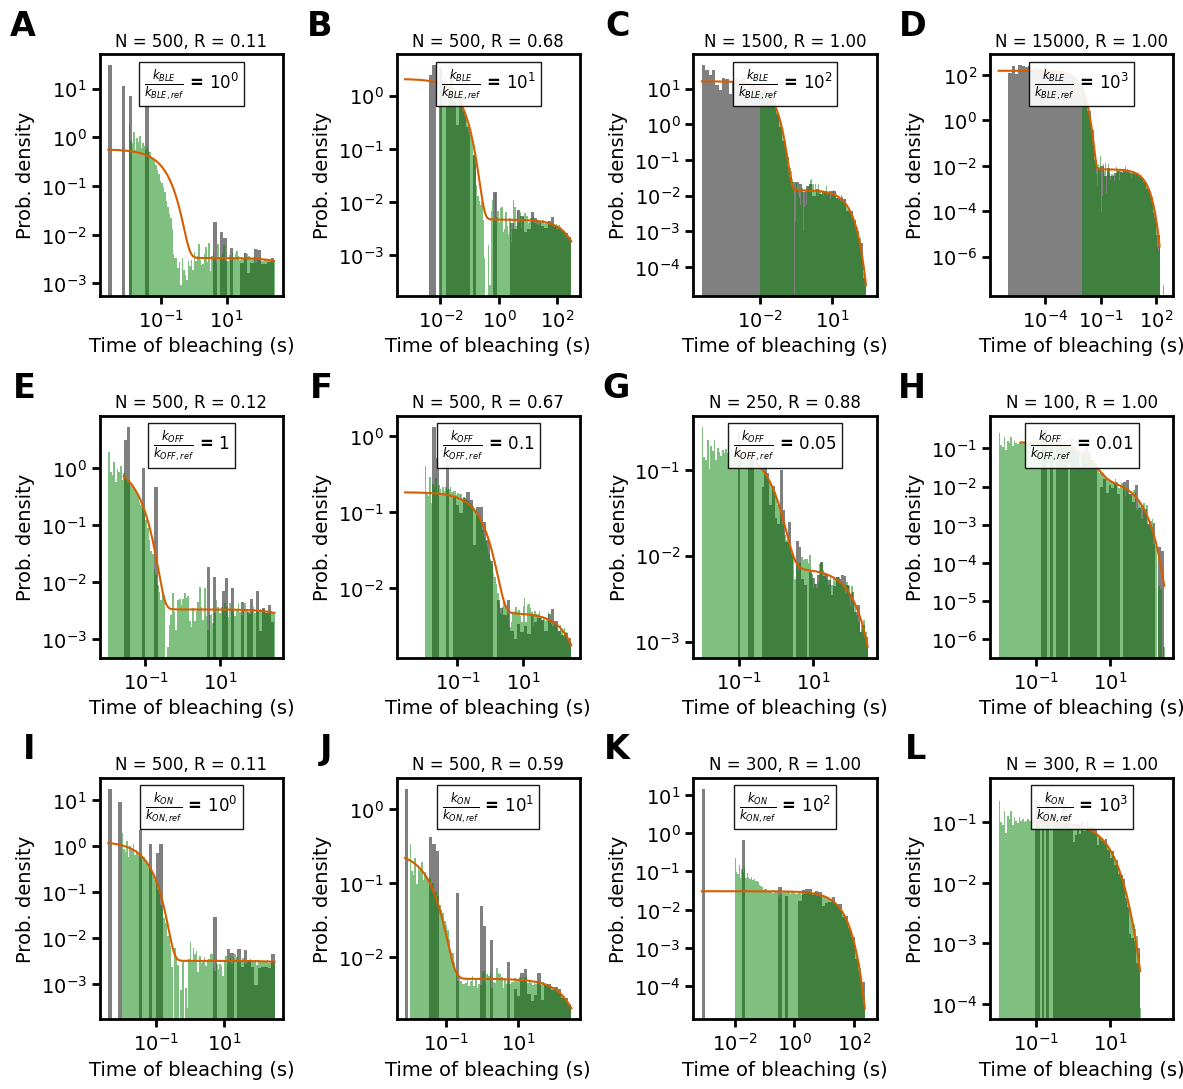

In [23]:
red = "#D55E00"
color = "grey"
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(12, 11))
label1 = [
    r"$\frac{k_{BLE}}{k_{BLE,ref}}$",
    r"$\frac{k_{OFF}}{k_{OFF,ref}}$",
    r"$\frac{k_{ON}}{k_{ON,ref}}$",
]
label2 = [
    [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"],
    [r"$1$", r"$0.1$", r"$0.05$", r"$0.01$"],
    [r"$10^{0}$", r"$10^{1}$", r"$10^{2}$", r"$10^{3}$"],
]

for i, (bleaching_times_all, hists_all, parameters_all_fit_cdf) in enumerate(
    zip(
        [bleaching_times_all_A, bleaching_times_all_B, bleaching_times_all_C],
        [hists_A, hists_B, hists_C],
        [parameters_all_fit_cdf_A, parameters_all_fit_cdf_B, parameters_all_fit_cdf_C],
    )
):
    for j, (bl_times, parameters, hists) in enumerate(
        zip(bleaching_times_all, parameters_all_fit_cdf, hists_all)
    ):
        pi, lambda1, lambda2 = parameters
        data = bl_times[:, 0][~np.isnan(bl_times[:, 0])]
        ratio = data.size / bl_times.shape[0]
        bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
        x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 1000)
        ax = fig.add_subplot(gs[i, j])
        fi.universal_figure(
            type_="hist", data=data, axes=ax, density=True, color=color, bins=bins
        )
        densities = hists / bin_widths
        fi.universal_figure(
            type_="bar",
            data=[bin_centers, densities],
            axes=ax,
            color="green",
            width=bin_widths,
            alpha=0.5,
        )
        fi.universal_figure(
            type_="line",
            data=[
                x,
                dist.ExponentialMixtureModel(
                    params={"pis": [pi], "lambdas": [lambda1, lambda2]}, domain=(0, 300)
                ).pdf(x),
            ],
            axes=ax,
            yscale="log",
            xscale="log",
            xlabel="Time of bleaching (s)",
            ylabel="Prob. density",
            color=red,
            fontsize=14,
        )
        props = dict(boxstyle="square", facecolor="white", alpha=0.9, edgecolor="black")
        ax.text(
            0.5,
            0.95,
            f"{label1[i]} = {label2[i][j]}",
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            va="top",
            ha="center",
            bbox=props,
        )
        ax.set_title(f"N = {bl_times.size}, R = {ratio:.2f}")

axes = fig.get_axes()
letters = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"]
for i, axis in enumerate(axes):
    offset = -0.35
    axis.text(
        offset,
        1.05,
        letters[i],
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()